# Figure 5
## Time-lag analysis using Cross-Correlation
### Author: Martin Loza
### Date: 26/01/20

Cross-correlation analysis to identify time lags between lncRNA and TF expression, assuming lncRNA precedes TF.
This analysis focuses on gene pairs with non-perfect correlation (r < 1.0) from FANTOM5 time series datasets.

In [ ]:
# Change R language to English
Sys.setenv(LANGUAGE = "en") 

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggvenn)
    library(circlize)
    library(tidyr)
    library(cowplot)
})

# Local variables 
seed = 777
date = "260120"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
gray = "gray50"

text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

fantom_coexpression_results = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_FANTOM5_time_course_analyses/Results/Gene_pairs_FANTOM_expression/"
fantom_selected_pairs <- "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/11_Figure_FANTOM5/Results/selected_significant_gene_pairs_FANTOM_4_plotting_251230.tsv"
plots_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/11_Figure_FANTOM5/Plots/"
results_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/11_Figure_FANTOM5/Results/"

# Local Functions

# Function to parse time point string and convert to minutes
parse_time_to_minutes <- function(time_string) {
    # Expected formats: "00hr00min", "01hr20min", "05hr", "1day", "2days", etc.
    
    # Initialize
    total_minutes <- 0
    
    # Check for days
    if (grepl("day", time_string)) {
        days <- as.numeric(gsub("days?", "", time_string))
        total_minutes <- days * 24 * 60
    } 
    # Check for hours and minutes
    else if (grepl("hr", time_string)) {
        # Extract hours
        if (grepl("hr[0-9]+min", time_string)) {
            hours <- as.numeric(gsub("hr.*", "", time_string))
            minutes <- as.numeric(gsub(".*hr", "", gsub("min", "", time_string)))
            total_minutes <- hours * 60 + minutes
        } else {
            # Only hours (e.g., "05hr")
            hours <- as.numeric(gsub("hr.*", "", time_string))
            total_minutes <- hours * 60
        }
    }
    # Check for minutes only
    else if (grepl("min", time_string)) {
        total_minutes <- as.numeric(gsub("min", "", time_string))
    }
    
    return(total_minutes)
}

# Function to calculate time intervals and check if high resolution
# High resolution: all intervals < 60 minutes (1 hour)
check_time_resolution <- function(time_points, max_interval_minutes = 60) {
    # Parse all time points to minutes
    time_minutes <- sapply(time_points, parse_time_to_minutes)
    
    # Calculate intervals between consecutive time points
    if (length(time_minutes) < 2) {
        return(list(
            is_high_resolution = FALSE,
            max_interval = NA,
            mean_interval = NA,
            time_minutes = time_minutes,
            intervals = NA
        ))
    }
    
    intervals <- diff(time_minutes)
    max_interval <- max(intervals)
    mean_interval <- mean(intervals)
    
    is_high_resolution <- max_interval <= max_interval_minutes
    
    return(list(
        is_high_resolution = is_high_resolution,
        max_interval = max_interval,
        mean_interval = mean_interval,
        time_minutes = time_minutes,
        intervals = intervals
    ))
}

# Function to filter time points to keep only high-resolution consecutive points
# Returns indices of time points to keep (all intervals < max_interval_minutes)
filter_high_resolution_timepoints <- function(time_points, max_interval_minutes = 60) {
    # Parse all time points to minutes
    time_minutes <- sapply(time_points, parse_time_to_minutes)
    
    if (length(time_minutes) < 2) {
        return(1:length(time_points))
    }
    
    # Calculate intervals between consecutive time points
    intervals <- diff(time_minutes)
    
    # Find the first interval that exceeds the threshold
    # Keep all points up to (but not including) the first large gap
    large_gap_idx <- which(intervals >= max_interval_minutes)
    
    if (length(large_gap_idx) == 0) {
        # All intervals are small, keep all points
        indices_to_keep <- 1:length(time_points)
    } else {
        # Keep points up to the first large gap
        first_gap <- large_gap_idx[1]
        indices_to_keep <- 1:first_gap
    }
    
    return(list(
        indices = indices_to_keep,
        n_original = length(time_points),
        n_kept = length(indices_to_keep),
        time_points_kept = time_points[indices_to_keep],
        removed_after = ifelse(length(large_gap_idx) > 0, 
                              paste0("time point ", first_gap, ": ", time_points[first_gap]), 
                              "none")
    ))
}

# Function to calculate cross-correlation with time lags
# Assuming lncRNA expression precedes TF expression
calculate_cross_correlation <- function(lncrna_expr, tf_expr, max_lag = NULL) {
    # If max_lag is not specified, use half the length of the time series
    if (is.null(max_lag)) {
        max_lag <- floor(length(lncrna_expr) / 2)
    }
    
    # Scale the expression values (z-score normalization)
    lncrna_scaled <- scale(lncrna_expr)[,1]
    tf_scaled <- scale(tf_expr)[,1]
    
    # Calculate cross-correlation
    # ccf calculates correlation between x[t+k] and y[t]
    # Positive lag means lncRNA leads TF (lncRNA precedes TF)
    ccf_result <- ccf(lncrna_scaled, tf_scaled, 
                      lag.max = max_lag, 
                      plot = FALSE)
    
    # Extract lag and correlation values
    lags <- ccf_result$lag
    correlations <- ccf_result$acf
    
    # Find the lag with maximum absolute correlation across all lags
    # Positive lag means lncRNA leads TF (lncRNA precedes TF)
    # Negative lag means TF leads lncRNA (TF precedes lncRNA)
    max_corr_idx <- which.max(abs(correlations))
    optimal_lag <- lags[max_corr_idx]
    max_correlation <- correlations[max_corr_idx]
    
    return(list(
        lags = lags,
        correlations = correlations,
        optimal_lag = optimal_lag,
        max_correlation = max_correlation,
        ccf_result = ccf_result
    ))
}

# Function to create cross-correlation plot
create_ccf_plot <- function(ccf_data, gene_pair_name, dataset_name, 
                           pearson_r = NA,
                           text_size = 18) {
    # Create data frame for plotting
    ccf_df <- data.frame(
        Lag = ccf_data$lags,
        Correlation = ccf_data$correlations
    )
    
    # Assign direction based on lag:
    # Positive lags: lncRNA leads TF (lncRNA expression precedes TF)
    # Negative lags: TF leads lncRNA (TF expression precedes lncRNA)
    # Zero lag: Synchronous (no lead)
    ccf_df$Direction <- ifelse(ccf_df$Lag > 0, "lncRNA leads", 
                              ifelse(ccf_df$Lag < 0, "TF leads", "Synchronous"))
    
    # Create plot
    p <- ggplot(ccf_df, aes(x = Lag, y = Correlation, fill = Direction)) +
        geom_bar(stat = "identity", width = 0.8, alpha = 0.7) +
        geom_hline(yintercept = 0, linetype = "solid", color = "black") +
        # Add significance lines (approximate 95% CI)
        geom_hline(yintercept = c(-1.96/sqrt(length(ccf_data$lags)), 
                                   1.96/sqrt(length(ccf_data$lags))), 
                   linetype = "dashed", color = "blue", alpha = 0.5) +
        # Highlight optimal lag
        geom_vline(xintercept = ccf_data$optimal_lag, 
                   linetype = "dashed", color = "red", linewidth = 1) +
        scale_fill_manual(values = c("lncRNA leads" = purple, "TF leads" = gray, "Synchronous" = "lightgray")) +
        labs(
            title = gene_pair_name,
            subtitle = paste0("Optimal lag: ", ccf_data$optimal_lag, 
                            " (max r = ", round(ccf_data$max_correlation, 3), ")"),
            x = "Lag (time points)",
            y = "Cross-correlation",
            fill = "Direction"
        ) +
        theme_classic() +
        theme(
            text = element_text(size = text_size),
            plot.title = element_text(face = "bold", size = text_size),
            plot.subtitle = element_text(size = text_size - 2),
            axis.title = element_text(size = text_size - 2),
            axis.text = element_text(size = text_size - 4),
            legend.position = "bottom",
            legend.title = element_text(face = "bold"),
            legend.text = element_text(size = text_size - 4)
        )
    
    return(p)
}

# Function to create combined plot: time series + cross-correlation
create_combined_plot <- function(data_row, dataset_name, 
                                max_lag = NULL,
                                scale_data = TRUE,
                                alpha = 0.8,
                                x_text_size = text_size - 2,
                                title_text_size = text_size,
                                max_interval_minutes = 60) {
    # Extract time point columns for lncRNA and TF
    lncrna_cols <- grep("^lncRNA_tpm_", colnames(data_row), value = TRUE)
    tf_cols <- grep("^TF_tpm_", colnames(data_row), value = TRUE)
    
    # Extract expression values
    lncrna_expr <- as.numeric(data_row[lncrna_cols])
    tf_expr <- as.numeric(data_row[tf_cols])
    
    # Extract time points from column names
    time_points <- gsub("lncRNA_tpm_.*_", "", lncrna_cols)
    
    # Filter to keep only high-resolution consecutive time points
    filter_result <- filter_high_resolution_timepoints(time_points, max_interval_minutes)
    indices_to_keep <- filter_result$indices
    
    # Apply filtering to time points and expression data
    time_points <- time_points[indices_to_keep]
    lncrna_expr <- lncrna_expr[indices_to_keep]
    tf_expr <- tf_expr[indices_to_keep]
    
    # Get gene names
    gene_name <- data_row$gene_name_pair_id.x
    if (is.na(gene_name)) {
        gene_name <- data_row$gene_pair_id
    }
    gene_names <- strsplit(gene_name, "_")[[1]]
    lncrna_name <- gene_names[1]
    tf_name <- gene_names[2]
    gene_pair_label <- str_replace(gene_name, pattern = "_", replacement = "/")
    
    # Calculate cross-correlation on filtered data
    ccf_data <- calculate_cross_correlation(lncrna_expr, tf_expr, max_lag)
    
    # Scale expression values for plotting
    if (scale_data) {
        lncrna_scaled <- scale(lncrna_expr)[,1]
        tf_scaled <- scale(tf_expr)[,1]
        expr_values <- c(lncrna_scaled, tf_scaled)
        y_label <- "Scaled TSS expression"
    } else {
        expr_values <- c(lncrna_expr, tf_expr)
        y_label <- "TSS expression (TPM)"
    }
    
    # Create time series plot
    plot_data <- data.frame(
        TimePoint = rep(time_points, 2),
        Expression = expr_values,
        Gene = rep(c(lncrna_name, tf_name), each = length(time_points)),
        Order = rep(seq_along(time_points), 2)
    )
    plot_data$Gene <- factor(plot_data$Gene, levels = c(lncrna_name, tf_name))
    
    pearson_r <- data_row$pearson_correlation
    
    # Create subtitle with filtering information
    # subtitle_text <- paste0("n = ", filter_result$n_kept, " time points")
    # if (filter_result$n_kept < filter_result$n_original) {
    #     subtitle_text <- paste0(subtitle_text, " (", filter_result$n_original - filter_result$n_kept, 
    #                            " removed after ", filter_result$removed_after, ")")
    # }
    
    p_timeseries <- ggplot(plot_data, aes(x = Order, y = Expression, color = Gene, group = Gene)) +
        geom_line(linewidth = line_size, alpha = alpha) +
        geom_point(size = dot_size, alpha = alpha) +
        scale_color_manual(values = c(purple, green)) +
        scale_x_continuous(breaks = 1:length(time_points), labels = time_points) +
        labs(
            title = paste0(dataset_name, " - ", gene_pair_label),
            # subtitle = subtitle_text,
            x = "Time Point",
            y = y_label,
            color = "Gene"
        ) +
        theme_classic() +
        theme(
            text = element_text(size = text_size),
            plot.title = element_text(face = "bold", size = title_text_size),
            plot.subtitle = element_text(size = title_text_size - 4),
            axis.title = element_text(size = title_text_size - 2),
            axis.text = element_text(size = x_text_size),
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "bottom",
            legend.title = element_text(face = "bold")
        )
    
    # Create cross-correlation plot
    p_ccf <- create_ccf_plot(ccf_data, gene_pair_label, dataset_name, 
                            pearson_r = pearson_r, 
                            text_size = text_size)
    
    # Return both plots, ccf data, and filter information
    return(list(
        timeseries_plot = p_timeseries,
        ccf_plot = p_ccf,
        ccf_data = ccf_data,
        filter_info = filter_result
    ))
}

### Load and setup the data

In [125]:
datasets <- c("Lymphatic", "Aortic", "MCF7", "Monocyte-derived", "Saos-2")

data_list <- lapply(datasets, function(dataset) {
    # Load data
    data_file <- paste0(fantom_coexpression_results, dataset, "_251230.tsv")
    data <- read.table(data_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    data$Dataset <- dataset
    return(data)
})

head(data_list[[1]])

,gene_pair_id,gene_name_pair_id,lncRNA_Family,avg_correlation,overall_rank,is_DT,is_AS,ncrna_tss,pcg_tss,chromosome,⋯,TF_tpm_Lymphatic_02hr00min,TF_tpm_Lymphatic_02hr30min,TF_tpm_Lymphatic_03hr00min,TF_tpm_Lymphatic_03hr30min,TF_tpm_Lymphatic_04hr,TF_tpm_Lymphatic_05hr,TF_tpm_Lymphatic_06hr,TF_tpm_Lymphatic_07hr,TF_tpm_Lymphatic_08hr,Dataset
,<chr>,<chr>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSG00000227640_ENSG00000125285,SOX21-AS1_SOX21,HMG,0.9682961,1,FALSE,TRUE,94712716,94712545,13,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
2,ENSG00000263146_ENSG00000256463,LINC01896_SALL3,zf-C2H2,0.9499586,2,FALSE,FALSE,78979074,78979818,18,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
3,ENSG00000277268_ENSG00000273706,LHX1-DT_LHX1,Homeobox,0.9465009,3,TRUE,FALSE,36936670,36936784,17,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
4,ENSG00000236502_ENSG00000138083,SIX3-AS1_SIX3,Homeobox,0.9460684,4,FALSE,TRUE,44941582,44941702,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
5,ENSG00000255399_ENSG00000089225,TBX5-AS1_TBX5,T-box,0.9433313,5,FALSE,TRUE,114408426,114408442,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
6,ENSG00000240990_ENSG00000005073,HOXA11-AS_HOXA11,Homeobox,0.9392763,6,FALSE,TRUE,27185235,27185232,7,⋯,0.2524562,0.1809412,0.3409931,0.3568161,0.1989531,0.254626,0.3412625,0.1461522,0.53154,Lymphatic


### Check temporal resolution of datasets

We need to identify which datasets have high-resolution time series (< 1 hour between samples) for meaningful cross-correlation analysis

In [126]:
# Check temporal resolution for each dataset
dataset_resolution_info <- list()

for (i in seq_along(data_list)) {
    dataset_name <- unique(data_list[[i]]$Dataset)[1]
    
    # Get time point columns
    sample_row <- data_list[[i]][1, ]
    lncrna_cols <- grep("^lncRNA_tpm_", colnames(sample_row), value = TRUE)
    time_points <- gsub("lncRNA_tpm_.*_", "", lncrna_cols)
    
    # Check resolution
    resolution_info <- check_time_resolution(time_points, max_interval_minutes = 60)
    
    dataset_resolution_info[[dataset_name]] <- list(
        dataset = dataset_name,
        n_timepoints = length(time_points),
        is_high_resolution = resolution_info$is_high_resolution,
        max_interval_minutes = resolution_info$max_interval,
        mean_interval_minutes = resolution_info$mean_interval,
        time_points = time_points
    )
    
    cat("\n", dataset_name, ":\n", sep = "")
    cat("  Number of time points:", length(time_points), "\n")
    cat("  Time range:", time_points[1], "to", time_points[length(time_points)], "\n")
    cat("  Max interval between samples:", round(resolution_info$max_interval, 2), "minutes\n")
    cat("  Mean interval between samples:", round(resolution_info$mean_interval, 2), "minutes\n")
    cat("  High resolution (< 60 min):", resolution_info$is_high_resolution, "\n")
}

# Create summary data frame
resolution_summary <- do.call(rbind, lapply(dataset_resolution_info, function(x) {
    data.frame(
        Dataset = x$dataset,
        N_timepoints = x$n_timepoints,
        High_resolution = x$is_high_resolution,
        Max_interval_min = round(x$max_interval_minutes, 2),
        Mean_interval_min = round(x$mean_interval_minutes, 2)
    )
}))

cat("\n\nSummary:\n")
print(resolution_summary)

# Filter for high-resolution datasets only
high_res_datasets <- resolution_summary %>%
    filter(High_resolution == TRUE) %>%
    pull(Dataset)

cat("\n\nHigh-resolution datasets (< 60 min between samples):\n")
print(high_res_datasets)


Lymphatic:
  Number of time points: 16 
  Time range: 00hr00min to 08hr 
  Max interval between samples: 60 minutes
  Mean interval between samples: 32 minutes
  High resolution (< 60 min): TRUE 

Aortic:
  Number of time points: 10 
  Time range: 00hr00min to 06hr 
  Max interval between samples: 60 minutes
  Mean interval between samples: 40 minutes
  High resolution (< 60 min): TRUE 

MCF7:
  Number of time points: 16 
  Time range: 00hr00min to 08hr 
  Max interval between samples: 60 minutes
  Mean interval between samples: 32 minutes
  High resolution (< 60 min): TRUE 

Monocyte-derived:
  Number of time points: 25 
  Time range: 00hr00min to 48hr 
  Max interval between samples: 720 minutes
  Mean interval between samples: 120 minutes
  High resolution (< 60 min): FALSE 

Saos-2:
  Number of time points: 18 
  Time range: 00hr00min to day28 
  Max interval between samples: 10080 minutes
  Mean interval between samples: 2371.76 minutes
  High resolution (< 60 min): FALSE 


Summ

Let's merge the coexpression results across datasets

In [127]:
# Load selected significant gene pairs from previous analyses
selected_fantom <- read.table(fantom_selected_pairs, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
head(selected_fantom)

,gene_pair_id,lncRNA_gene_id,TF_gene_id,n_samples,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr,⋯,ncrna_tss,pcg_tss,Family,abs_strand_distance,gene_name_pair_id,avg_correlation,overall_rank,is_DT,is_AS,num_datasets_significant
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>
1,ENSG00000240990_ENSG00000005073,ENSG00000240990_27185235,ENSG00000005073_27185232,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,27185235,27185232,Homeobox,3,HOXA11-AS_HOXA11,0.9392763,6,FALSE,TRUE,2
2,ENSG00000230844_ENSG00000251192,ENSG00000230844_46545438,ENSG00000251192_46545441,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,46545438,46545441,zf-C2H2,3,ZNF674-AS1_ZNF674,0.8993300,18,FALSE,TRUE,2
3,ENSG00000225733_ENSG00000177463,ENSG00000225733_14947538,ENSG00000177463_14947544,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,14947538,14947544,RXR-like,6,FGD5-AS1_NR2C2,0.8207711,74,FALSE,TRUE,5
4,ENSG00000283122_ENSG00000118495,ENSG00000283122_144008262,ENSG00000118495_144008261,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,144008262,144008261,zf-C2H2,1,HYMAI_PLAGL1,0.8193061,76,FALSE,FALSE,5
5,ENSG00000269834_ENSG00000167555,ENSG00000269834_52397807,ENSG00000167555_52397849,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,52397807,52397849,zf-C2H2,42,ZNF528-AS1_ZNF528,0.8058113,91,FALSE,TRUE,5
6,ENSG00000267886_ENSG00000183850,ENSG00000267886_23075211,ENSG00000183850_23075210,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,23075211,23075210,zf-C2H2,1,unnamed_ZNF730,0.8014170,97,FALSE,FALSE,2


In [128]:
# Filter gene pairs with correlation < 1.0 (not perfect correlation)
# Focus on non-perfect correlating pairs for time-lag analysis
non_perfect_pairs <- selected_fantom %>%
    filter(pearson_correlation < 1.0) %>%
    arrange(desc(pearson_correlation))

cat("Number of gene pairs with non-perfect correlation:", nrow(non_perfect_pairs), "\n")
cat("Correlation range:", min(non_perfect_pairs$pearson_correlation), "-", max(non_perfect_pairs$pearson_correlation), "\n")
head(non_perfect_pairs)

Number of gene pairs with non-perfect correlation: 13 
Correlation range: 0.4902893 - 0.9958994 


,gene_pair_id,lncRNA_gene_id,TF_gene_id,n_samples,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr,⋯,ncrna_tss,pcg_tss,Family,abs_strand_distance,gene_name_pair_id,avg_correlation,overall_rank,is_DT,is_AS,num_datasets_significant
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>
1,ENSG00000226471_ENSG00000100219,ENSG00000226471_28800655,ENSG00000100219_28800597,16,0.9958994,5.170978e-16,1.093861e-15,0.9647059,1.666208e-09,3.394127e-09,⋯,28800655,28800597,TF_bZIP,58,unnamed_XBP1,0.4972102,251,FALSE,FALSE,1
2,ENSG00000285205_ENSG00000133937,ENSG00000285205_94770271,ENSG00000133937_94770113,16,0.9925369,3.390448e-14,6.906467e-14,0.9823529,1.364124e-11,2.885647e-11,⋯,94770271,94770113,Homeobox,158,GSC-DT_GSC,0.7736821,119,TRUE,FALSE,1
3,ENSG00000269834_ENSG00000167555,ENSG00000269834_52397807,ENSG00000167555_52397849,25,0.9652663,6.659359e-15,9.009721e-15,0.9646154,8.218110e-15,1.111862e-14,⋯,52397807,52397849,zf-C2H2,42,ZNF528-AS1_ZNF528,0.8058113,91,FALSE,TRUE,5
4,ENSG00000233527_ENSG00000186020,ENSG00000233527_36573321,ENSG00000186020_36573292,16,0.9465904,2.884830e-08,5.666630e-08,0.9323529,1.451754e-07,2.851661e-07,⋯,36573321,36573292,zf-C2H2,29,ZNF529-AS1_ZNF529,0.8046477,94,FALSE,TRUE,3
5,ENSG00000233527_ENSG00000186020,ENSG00000233527_36573321,ENSG00000186020_36573292,25,0.8745126,1.100288e-08,1.405923e-08,0.8676923,1.952951e-08,2.495437e-08,⋯,36573321,36573292,zf-C2H2,29,ZNF529-AS1_ZNF529,0.8046477,94,FALSE,TRUE,3
6,ENSG00000283103_ENSG00000182318,ENSG00000283103_58326967,ENSG00000182318_58326994,16,0.8678592,1.320740e-05,2.504851e-05,0.7117647,1.984043e-03,3.762841e-03,⋯,58326967,58326994,zf-C2H2,27,unnamed_ZSCAN22,0.7448771,147,FALSE,FALSE,1


In [129]:
# Process ALL non-perfect correlation pairs from all datasets
# Time point filtering will be applied within each pair to keep only high-resolution portions

gene_pairs_with_data <- list()

for (i in seq_along(data_list)) {
    dataset_name <- unique(data_list[[i]]$Dataset)[1]
    
    # Find which non-perfect pairs are in this dataset
    pairs_in_dataset <- non_perfect_pairs %>%
        filter(Dataset == dataset_name) %>%
        inner_join(data_list[[i]], by = c("gene_pair_id", "Dataset"))
    
    if (nrow(pairs_in_dataset) > 0) {
        gene_pairs_with_data[[dataset_name]] <- pairs_in_dataset
        cat(dataset_name, ":", nrow(pairs_in_dataset), "gene pairs (time points will be filtered to high-resolution)\n")
    }
}

# Show summary of available gene pairs
cat("\nTotal datasets with non-perfect correlation pairs:", length(gene_pairs_with_data), "\n")

# Display gene pairs available for analysis
for (dataset_name in names(gene_pairs_with_data)) {
    cat("\n", dataset_name, ":\n", sep = "")
    summary_df <- gene_pairs_with_data[[dataset_name]] %>%
        select(gene_pair_id, gene_name_pair_id.x, pearson_correlation, lncRNA_Family) %>%
        distinct() %>%
        arrange(desc(pearson_correlation))
    print(summary_df)
}

Aortic : 1 gene pairs (time points will be filtered to high-resolution)
MCF7 : 5 gene pairs (time points will be filtered to high-resolution)
Monocyte-derived : 5 gene pairs (time points will be filtered to high-resolution)
Saos-2 : 2 gene pairs (time points will be filtered to high-resolution)

Total datasets with non-perfect correlation pairs: 4 

Aortic:
                     gene_pair_id gene_name_pair_id.x pearson_correlation
1 ENSG00000257178_ENSG00000182742       unnamed_HOXB4           0.6867746
  lncRNA_Family
1      Homeobox

MCF7:
                     gene_pair_id gene_name_pair_id.x pearson_correlation
1 ENSG00000226471_ENSG00000100219        unnamed_XBP1           0.9958994
2 ENSG00000285205_ENSG00000133937          GSC-DT_GSC           0.9925369
3 ENSG00000233527_ENSG00000186020   ZNF529-AS1_ZNF529           0.9465904
4 ENSG00000283103_ENSG00000182318     unnamed_ZSCAN22           0.8678592
5 ENSG00000213888_ENSG00000100105     LINC01521_PATZ1           0.6153948
  lncRNA_

### Cross-Correlation Analysis

Perform time-lag analysis for non-perfect correlating pairs using cross-correlation.
We assume lncRNA expression precedes TF expression.

**Important:** For each gene pair, we filter time points to keep only consecutive points with intervals < 60 minutes.
This ensures consistent high-resolution analysis even for datasets with mixed temporal scales (e.g., minutes early, hours/days later).

In [130]:
# Perform cross-correlation analysis for each gene pair
ccf_results_list <- list()
combined_plots_list <- list()

for (dataset_name in names(gene_pairs_with_data)) {
    dataset_pairs <- gene_pairs_with_data[[dataset_name]]
    
    for (i in 1:nrow(dataset_pairs)) {
        data_row <- dataset_pairs[i, ]
        
        # Create combined plots (time series + CCF)
        # Time points will be filtered to keep only high-resolution consecutive points
        combined <- create_combined_plot(data_row, dataset_name,
                                        max_lag = 3,  # Limit to +-3 lags
                                        scale_data = TRUE,
                                        alpha = 0.6,
                                        x_text_size = text_size - 5,
                                        title_text_size = text_size - 2,
                                        max_interval_minutes = 60)  # Keep only intervals < 60 min
        
        plot_name <- paste0(data_row$gene_pair_id, "_", dataset_name)
        combined_plots_list[[plot_name]] <- combined
        
        # Store CCF results for summary including filtering info
        ccf_results_list[[plot_name]] <- data.frame(
            gene_pair_id = data_row$gene_pair_id,
            gene_name_pair = data_row$gene_name_pair_id.x,
            Dataset = dataset_name,
            pearson_correlation = data_row$pearson_correlation,
            optimal_lag = combined$ccf_data$optimal_lag,
            max_ccf_correlation = combined$ccf_data$max_correlation,
            lncRNA_Family = data_row$lncRNA_Family,
            n_timepoints_used = combined$filter_info$n_kept,
            n_timepoints_original = combined$filter_info$n_original,
            timepoints_removed = combined$filter_info$n_original - combined$filter_info$n_kept
        )
    }
}

# Combine all CCF results into a single data frame
ccf_results_df <- do.call(rbind, ccf_results_list)
rownames(ccf_results_df) <- NULL

cat("\nCross-correlation analysis completed for", nrow(ccf_results_df), "gene pairs\n")
ccf_results_df


Cross-correlation analysis completed for 13 gene pairs


gene_pair_id,gene_name_pair,Dataset,pearson_correlation,optimal_lag,max_ccf_correlation,lncRNA_Family,n_timepoints_used,n_timepoints_original,timepoints_removed
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>
ENSG00000257178_ENSG00000182742,unnamed_HOXB4,Aortic,0.6867746,0,0.7585746,Homeobox,5,10,5
ENSG00000226471_ENSG00000100219,unnamed_XBP1,MCF7,0.9958994,0,0.9898887,TF_bZIP,12,16,4
ENSG00000285205_ENSG00000133937,GSC-DT_GSC,MCF7,0.9925369,0,0.9916269,Homeobox,12,16,4
ENSG00000233527_ENSG00000186020,ZNF529-AS1_ZNF529,MCF7,0.9465904,0,0.9493937,zf-C2H2,12,16,4
ENSG00000283103_ENSG00000182318,unnamed_ZSCAN22,MCF7,0.8678592,0,0.6992616,zf-C2H2,12,16,4
ENSG00000213888_ENSG00000100105,LINC01521_PATZ1,MCF7,0.6153948,0,0.4342751,ZBTB,12,16,4
ENSG00000269834_ENSG00000167555,ZNF528-AS1_ZNF528,Monocyte-derived,0.9652663,0,0.9901576,zf-C2H2,11,25,14
ENSG00000233527_ENSG00000186020,ZNF529-AS1_ZNF529,Monocyte-derived,0.8745126,0,0.7561990,zf-C2H2,11,25,14
ENSG00000237149_ENSG00000165655,ZNF503-AS2_ZNF503,Monocyte-derived,0.8209894,-1,0.8151769,Others,11,25,14


In [131]:
# Check the time point columns to understand temporal resolution
sample_data <- data_list[[1]]
time_cols <- grep("^lncRNA_tpm_", colnames(sample_data), value = TRUE)
cat("Sample time point columns:\n")
print(head(time_cols, 10))

# Extract time points
time_points <- gsub("lncRNA_tpm_.*_", "", time_cols)
cat("\nExtracted time points:\n")
print(time_points)

Sample time point columns:
 [1] "lncRNA_tpm_Lymphatic_00hr00min" "lncRNA_tpm_Lymphatic_00hr15min"
 [3] "lncRNA_tpm_Lymphatic_00hr30min" "lncRNA_tpm_Lymphatic_00hr45min"
 [5] "lncRNA_tpm_Lymphatic_01hr00min" "lncRNA_tpm_Lymphatic_01hr20min"
 [7] "lncRNA_tpm_Lymphatic_01hr40min" "lncRNA_tpm_Lymphatic_02hr00min"
 [9] "lncRNA_tpm_Lymphatic_02hr30min" "lncRNA_tpm_Lymphatic_03hr00min"

Extracted time points:
 [1] "00hr00min" "00hr15min" "00hr30min" "00hr45min" "01hr00min" "01hr20min"
 [7] "01hr40min" "02hr00min" "02hr30min" "03hr00min" "03hr30min" "04hr"     
[13] "05hr"      "06hr"      "07hr"      "08hr"     


In [132]:
# Test the filtering function on the sample data
filter_test <- filter_high_resolution_timepoints(time_points, max_interval_minutes = 60)
cat("Filtering test results:\n")
cat("Original time points:", filter_test$n_original, "\n")
cat("Time points kept:", filter_test$n_kept, "\n")
cat("Time points removed:", filter_test$n_original - filter_test$n_kept, "\n")
cat("Removed after:", filter_test$removed_after, "\n")
cat("\nKept time points:\n")
print(filter_test$time_points_kept)

Filtering test results:
Original time points: 16 
Time points kept: 12 
Time points removed: 4 


Removed after: time point 12: 04hr 

Kept time points:
 [1] "00hr00min" "00hr15min" "00hr30min" "00hr45min" "01hr00min" "01hr20min"
 [7] "01hr40min" "02hr00min" "02hr30min" "03hr00min" "03hr30min" "04hr"     


In [133]:
# Display CCF results summary (no saving yet)
cat("\nCross-correlation analysis summary:\n")
cat("Total gene pairs analyzed:", nrow(ccf_results_df), "\n\n")

cat("Time point filtering summary:\n")
cat("Mean time points used:", round(mean(ccf_results_df$n_timepoints_used), 1), "\n")
cat("Mean time points removed:", round(mean(ccf_results_df$timepoints_removed), 1), "\n")
cat("Pairs with filtered time points:", sum(ccf_results_df$timepoints_removed > 0), "/", nrow(ccf_results_df), "\n\n")

cat("Summary of optimal lags:\n")
print(summary(ccf_results_df$optimal_lag))

cat("\nSummary of max CCF correlations:\n")
print(summary(ccf_results_df$max_ccf_correlation))

cat("\nDistribution of optimal lags:\n")
print(table(ccf_results_df$optimal_lag))

cat("\nOptimal lag by dataset:\n")
lag_summary <- ccf_results_df %>% 
      group_by(Dataset) %>% 
      summarise(
          n_pairs = n(),
          mean_lag = mean(optimal_lag),
          median_lag = median(optimal_lag),
          mean_max_ccf = mean(max_ccf_correlation),
          mean_pearson = mean(pearson_correlation),
          mean_timepoints_used = mean(n_timepoints_used),
          mean_timepoints_removed = mean(timepoints_removed),
          .groups = "drop"
      )
print(lag_summary)

ccf_results_df


Cross-correlation analysis summary:
Total gene pairs analyzed: 13 

Time point filtering summary:
Mean time points used: 10.8 
Mean time points removed: 8.5 
Pairs with filtered time points: 13 / 13 

Summary of optimal lags:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     -1       0       0       0       0       1 

Summary of max CCF correlations:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-0.4186  0.6993  0.8152  0.7234  0.9899  0.9948 

Distribution of optimal lags:

-1  0  1 
 1 11  1 

Optimal lag by dataset:
# A tibble: 4 × 8
  Dataset          n_pairs mean_lag median_lag mean_max_ccf mean_pearson
  <chr>              <int>    <dbl>      <dbl>        <dbl>        <dbl>
1 Aortic                 1      0          0          0.759        0.687
2 MCF7                   5      0          0          0.813        0.884
3 Monocyte-derived       5     -0.2        0          0.826        0.755
4 Saos-2                 2      0.5        0.5        0.224        0.757
# ℹ 2 more

gene_pair_id,gene_name_pair,Dataset,pearson_correlation,optimal_lag,max_ccf_correlation,lncRNA_Family,n_timepoints_used,n_timepoints_original,timepoints_removed
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>
ENSG00000257178_ENSG00000182742,unnamed_HOXB4,Aortic,0.6867746,0,0.7585746,Homeobox,5,10,5
ENSG00000226471_ENSG00000100219,unnamed_XBP1,MCF7,0.9958994,0,0.9898887,TF_bZIP,12,16,4
ENSG00000285205_ENSG00000133937,GSC-DT_GSC,MCF7,0.9925369,0,0.9916269,Homeobox,12,16,4
ENSG00000233527_ENSG00000186020,ZNF529-AS1_ZNF529,MCF7,0.9465904,0,0.9493937,zf-C2H2,12,16,4
ENSG00000283103_ENSG00000182318,unnamed_ZSCAN22,MCF7,0.8678592,0,0.6992616,zf-C2H2,12,16,4
ENSG00000213888_ENSG00000100105,LINC01521_PATZ1,MCF7,0.6153948,0,0.4342751,ZBTB,12,16,4
ENSG00000269834_ENSG00000167555,ZNF528-AS1_ZNF528,Monocyte-derived,0.9652663,0,0.9901576,zf-C2H2,11,25,14
ENSG00000233527_ENSG00000186020,ZNF529-AS1_ZNF529,Monocyte-derived,0.8745126,0,0.7561990,zf-C2H2,11,25,14
ENSG00000237149_ENSG00000165655,ZNF503-AS2_ZNF503,Monocyte-derived,0.8209894,-1,0.8151769,Others,11,25,14


### Visualization of Cross-Correlation Results

Create plots showing cross-correlation patterns for each gene pair

In [134]:
# Create combined plots for each dataset showing both time series and CCF
# Note: We're not saving these yet - just preparing visualizations

all_timeseries_plots <- list()
all_ccf_plots <- list()

# Use all datasets that have data
datasets_to_plot <- names(gene_pairs_with_data)

for (dataset in datasets_to_plot) {
    # Get plots for this dataset
    sel_plots_names <- grep(dataset, names(combined_plots_list), value = TRUE)
    
    if (length(sel_plots_names) == 0) {
        cat("No data for dataset:", dataset, "\n")
        next
    }
    
    # Extract time series and CCF plots separately
    timeseries_plots <- list()
    ccf_plots <- list()
    
    for (plot_name in sel_plots_names) {
        combined <- combined_plots_list[[plot_name]]
        timeseries_plots[[plot_name]] <- combined$timeseries_plot
        ccf_plots[[plot_name]] <- combined$ccf_plot
    }
    
    n_plots <- length(sel_plots_names)
    
    # Create merged time series plots
    if (n_plots > 0) {
        merged_timeseries <- wrap_plots(timeseries_plots, ncol = 3) & 
            scale_color_manual(values = c(purple, green), labels = c("lncRNA", "TF")) &
            theme(legend.position = "bottom")
        merged_timeseries <- merged_timeseries + 
            plot_layout(guides = "collect") +
            plot_annotation(
                title = paste0("Time Series - ", dataset),
                theme = theme(plot.title = element_text(size = text_size + 4, face = "bold", hjust = 0.5))
            )
        
        all_timeseries_plots[[dataset]] <- merged_timeseries
        
        # Create merged CCF plots
        merged_ccf <- wrap_plots(ccf_plots, ncol = 3) &
            theme(legend.position = "bottom")
        merged_ccf <- merged_ccf + 
            plot_layout(guides = "collect") +
            plot_annotation(
                title = paste0("Cross-Correlation Analysis - ", dataset, " (filtered to < 60 min intervals)"),
                theme = theme(plot.title = element_text(size = text_size + 4, face = "bold", hjust = 0.5))
            )
        
        all_ccf_plots[[dataset]] <- merged_ccf
        
        cat("Prepared plots for", dataset, ":", n_plots, "gene pairs\n")
    }
}

cat("\nTotal datasets with plots prepared:", length(all_timeseries_plots), "\n")

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Prepared plots for Aortic : 1 gene pairs


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Prepared plots for MCF7 : 5 gene pairs


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Prepared plots for Monocyte-derived : 5 gene pairs


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Prepared plots for Saos-2 : 2 gene pairs

Total datasets with plots prepared: 4 


### Display All Plots for Exploration

Now showing ALL combined plots (time series + CCF) for all non-perfect correlation pairs


Created multi-panel figure with all 13 pairs for comparison


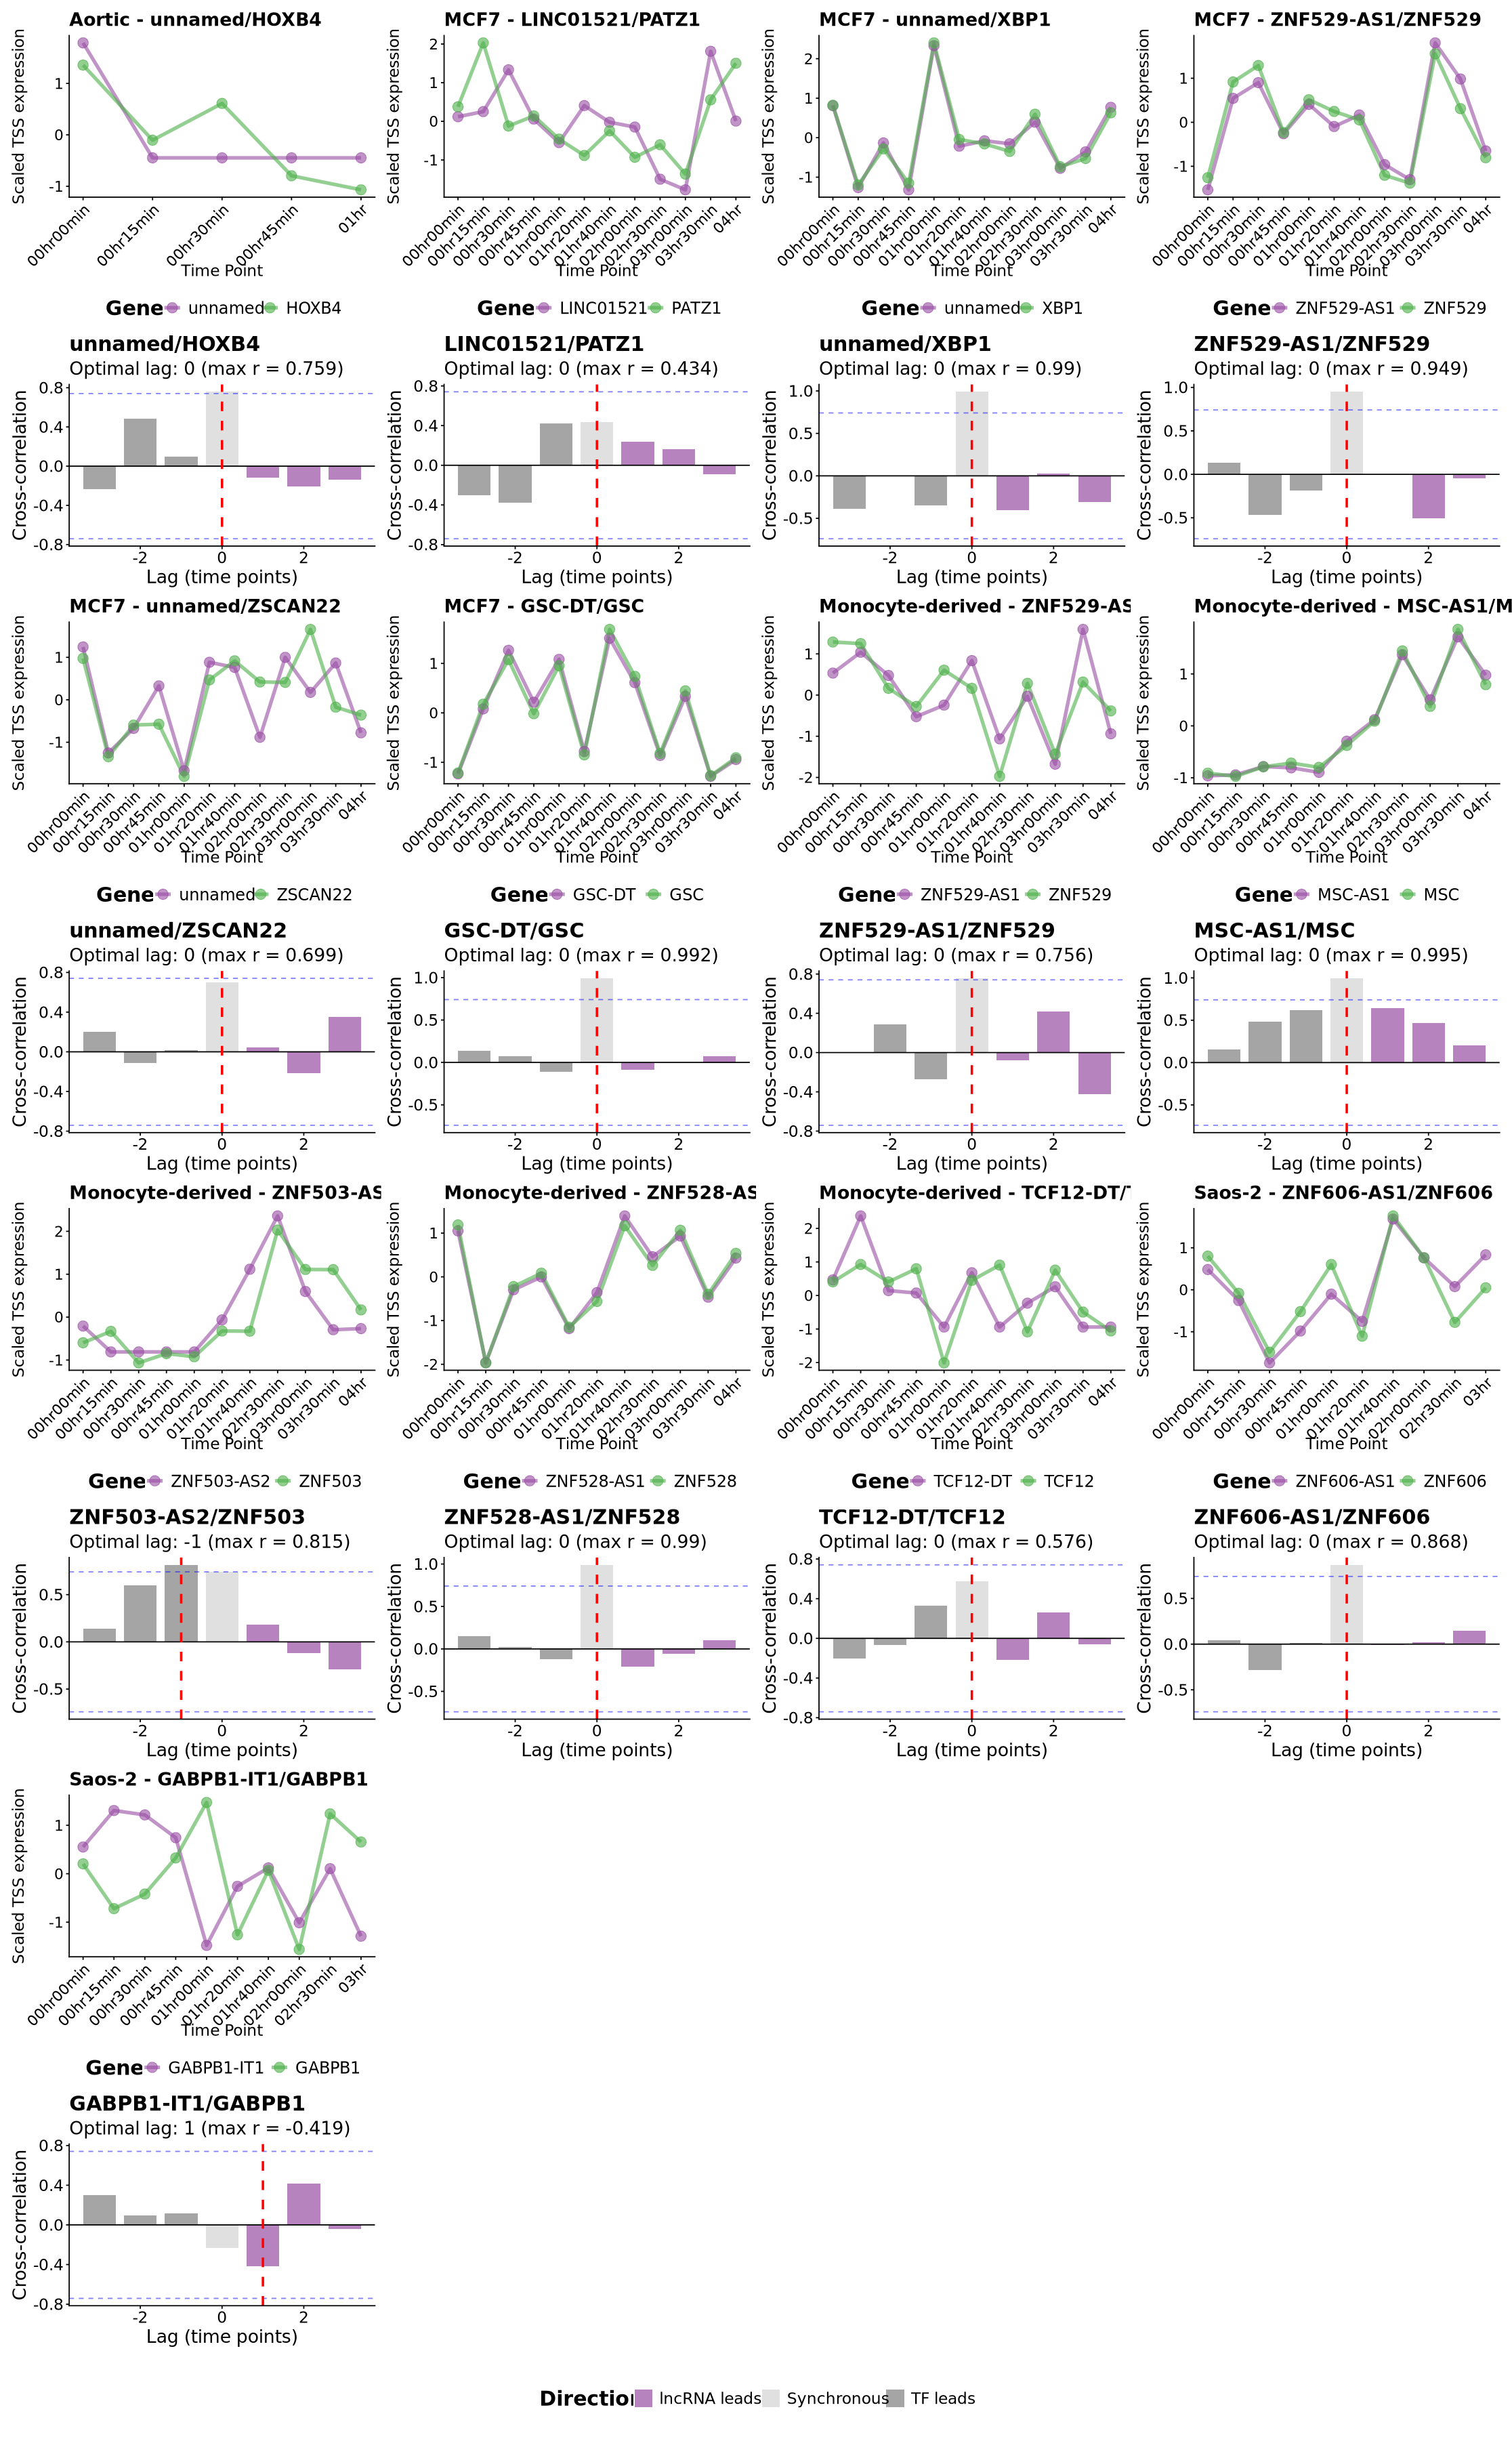

In [138]:
# Create a multi-panel figure with ALL pairs for comparison
# Include all 13 non-perfect correlation pairs
plot_pairs <- summary_plot_data %>%
    arrange(Dataset, gene_pair_id)


if (nrow(plot_pairs) >= 1) {
    # Create combined plots for ALL pairs
    n_plots <- nrow(plot_pairs)
    plot_combined_plots <- list()
    
    # Store one CCF plot with legend for the bottom
    first_pair <- plot_pairs[1, ]
    first_plot_name <- paste0(first_pair$gene_pair_id, "_", first_pair$Dataset)
    ccf_with_legend <- combined_plots_list[[first_plot_name]]$ccf_plot
    
    for (i in 1:n_plots) {
        pair <- plot_pairs[i, ]
        plot_name <- paste0(pair$gene_pair_id, "_", pair$Dataset)
        combined <- combined_plots_list[[plot_name]]
        
        # Remove legend from CCF plot (keep time series legend)
        ccf_no_legend <- combined$ccf_plot + theme(legend.position = "none")
        
        # Create a combined plot for this pair with CCF plot at 80% height
        combined_panel <- (combined$timeseries_plot / ccf_no_legend) +
            plot_layout(heights = c(1, 1)) +
            plot_annotation(tag_levels = list(c(LETTERS[i*2-1], LETTERS[i*2])))
        
        plot_combined_plots[[i]] <- combined_panel
    }
    
    # Arrange in a grid with 4 columns
    main_plots <- wrap_plots(plot_combined_plots, ncol = 4) +
        plot_annotation(
            theme = theme(plot.title = element_text(size = text_size + 6, face = "bold", hjust = 0.5))
        )
    
    # Create a separate legend plot at the bottom
    legend_plot <- cowplot::get_legend(ccf_with_legend + 
                                       theme(legend.position = "bottom",
                                             legend.box.margin = margin(t = 10)))
    
    # Combine main plots with legend at bottom
    final_plot <- main_plots / wrap_elements(full = legend_plot) +
        plot_layout(heights = c(1, 0.03))
    
    cat("\nCreated multi-panel figure with all", n_plots, "pairs for comparison\n")
}

# Adjust plot dimensions for all pairs
options(repr.plot.width = width, repr.plot.height = height * 1.5 * ceiling(n_plots / 4))
final_plot

In [ ]:
# Save merged plot to file
output_file <- paste0(plots_out_dir, "Supplementary_time_series_selected_cross_correlation", date, ".pdf")
ggsave(output_file, final_plot, width = width, height = (height)* ceiling(n_plots / 4), dpi = dpi)


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


